# FID vs. training step

Take a **dict of run output folders -> legend tags** (`RUN_DIRS` below), look in each `<run dir>/fid_eval/` for every per-checkpoint `*_fid.yaml` written by `scripts/calculate_fid_sweep.py`, and plot one `fid` vs. `step` curve per run -- labeled by its legend tag -- on a single shared final plot.

Runs are given by output folder rather than by config file, since several runs (e.g. different encoders, or a config edited between runs) can come from the same config path.

Reads the individual `<ckpt_stem>_fid.yaml` files (not the aggregated `fid_summary.yaml` in the same folder) so this stays correct even if a sweep is still in progress and only some checkpoints have been evaluated so far. To run: `scripts/calculate_fid_sweep.py --config <config path>` first, for each run in `RUN_DIRS`.

A run whose sweep hasn't produced any `*_fid.yaml` yet is skipped with a warning rather than aborting the whole notebook, so the other runs can still be plotted.

For local use (not Colab) -- no GPU, no model loading, just reading yaml files and plotting.

In [36]:
import os
import glob

import yaml
import numpy as np
import matplotlib.pyplot as plt

In [37]:
REPO_ROOT = ".."

In [38]:
# Map each run's output folder (relative to REPO_ROOT, as written by scripts/diffusion_train.py:
# <config output_dir>_<run tag>) to the legend label its curve should carry in the final plot.
RUN_DIRS = {
    "outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_uncond_z1": "Unconditional",
    "outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_alexnet_fc6_z50": "Conditional (AlexNet-fc6 PCA50)",
    "outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_alexnet_fc6_z200": "Conditional (AlexNet-fc6 PCA200)",
    "outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_dinov2_vitb14_z50": "Conditional (DINOv2 ViTb14 CLS PCA50)",
}

In [39]:
# `runs` accumulates one dict per run folder, filled in further by the cells below.
runs = [{"tag": tag, "run_dir": run_dir} for run_dir, tag in RUN_DIRS.items()]
for run in runs:
    print(f"[{run['tag']}] {run['run_dir']}")

[Unconditional] outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_uncond_z1
[Conditional (AlexNet-fc6 PCA50)] outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_alexnet_fc6_z50
[Conditional (AlexNet-fc6 PCA200)] outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_alexnet_fc6_z200
[Conditional (DINOv2 ViTb14 CLS PCA50)] outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_dinov2_vitb14_z50


In [40]:
# *_fid.yaml, not fid_summary.yaml (different schema: a stem -> {step, fid} mapping, rather
# than one flat {step, fid, ...} dict per file) -- see scripts/calculate_fid_sweep.py.
# A run with no *_fid.yaml yet is warned about and dropped, rather than aborting the whole
# notebook, so the other runs can still be plotted.
for run in runs:
    eval_dir = os.path.join(REPO_ROOT, run["run_dir"], "fid_eval")
    yaml_paths = sorted(glob.glob(os.path.join(eval_dir, "*_fid.yaml")))
    run["eval_dir"] = eval_dir
    run["yaml_paths"] = yaml_paths
    if yaml_paths:
        print(f"[{run['tag']}] Found {len(yaml_paths)} per-checkpoint FID yaml files in {eval_dir}")
    else:
        print(
            f"[{run['tag']}] No *_fid.yaml files found in {eval_dir} -- does the folder exist, and has "
            "scripts/calculate_fid_sweep.py been run for this run yet? Skipping."
        )

runs = [run for run in runs if run["yaml_paths"]]
assert runs, (
    "No run in RUN_DIRS has any *_fid.yaml files yet -- run scripts/calculate_fid_sweep.py "
    "for at least one run first."
)

[Unconditional] Found 13 per-checkpoint FID yaml files in ../outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_uncond_z1/fid_eval
[Conditional (AlexNet-fc6 PCA50)] Found 12 per-checkpoint FID yaml files in ../outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_alexnet_fc6_z50/fid_eval
[Conditional (AlexNet-fc6 PCA200)] Found 10 per-checkpoint FID yaml files in ../outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_alexnet_fc6_z200/fid_eval
[Conditional (DINOv2 ViTb14 CLS PCA50)] Found 2 per-checkpoint FID yaml files in ../outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_dinov2_vitb14_z50/fid_eval


In [41]:
for run in runs:
    steps, fids = [], []
    for p in run["yaml_paths"]:
        with open(p) as f:
            info = yaml.safe_load(f)
        steps.append(info["step"])
        fids.append(info["fid"])

    steps = np.array(steps)
    fids = np.array(fids)
    order = np.argsort(steps)
    run["steps"], run["fids"] = steps[order], fids[order]

    print(f"[{run['tag']}]")
    for s, fd in zip(run["steps"], run["fids"]):
        print(f"  step {s:>8,}   fid {fd:.3f}")

[Unconditional]
  step   25,000   fid 17.637
  step   50,000   fid 12.265
  step   75,000   fid 10.064
  step  100,000   fid 10.245
  step  125,000   fid 8.121
  step  150,000   fid 7.670
  step  175,000   fid 7.305
  step  200,000   fid 7.020
  step  225,000   fid 6.934
  step  250,000   fid 6.668
  step  275,000   fid 6.608
  step  300,000   fid 6.560
  step  325,000   fid 6.514
[Conditional (AlexNet-fc6 PCA50)]
  step   25,000   fid 14.882
  step   50,000   fid 12.275
  step   75,000   fid 11.421
  step  100,000   fid 11.041
  step  125,000   fid 10.751
  step  150,000   fid 10.625
  step  175,000   fid 10.502
  step  200,000   fid 10.504
  step  225,000   fid 10.546
  step  250,000   fid 10.581
  step  275,000   fid 10.467
  step  300,000   fid 10.385
[Conditional (AlexNet-fc6 PCA200)]
  step   25,000   fid 13.472
  step   50,000   fid 11.120
  step   75,000   fid 10.177
  step  100,000   fid 9.818
  step  125,000   fid 9.568
  step  150,000   fid 9.326
  step  175,000   fid 9.207


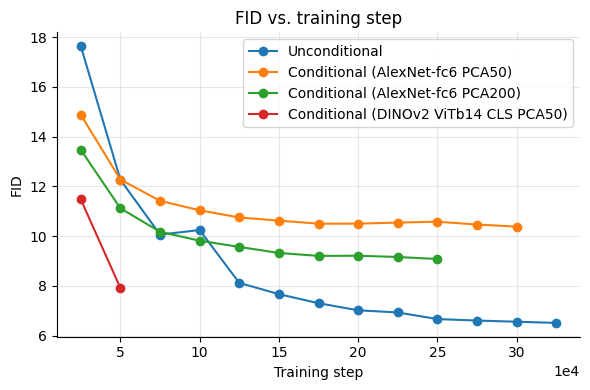

In [42]:
fig, ax = plt.subplots(figsize=(6, 4))
for run in runs:
    ax.plot(run["steps"], run["fids"], marker="o", label=run["tag"])
ax.set_xlabel("Training step")
ax.set_ylabel("FID")
ax.set_title("FID vs. training step")
ax.grid(alpha=0.3)
ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.ticklabel_format(style="sci", axis="x", scilimits=(4, 4))

plt.tight_layout()
plt.savefig("fid_vs_step.png")
plt.show()